In [99]:
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from networkx.algorithms import bipartite
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import time as TIME

In [100]:
#### NOTES

# Since there is no data on McNeir Hall, I deleted all busi exams
# I also deleted all musi exams 

# Data Manipulation

In [3]:
### Read the Data

classrooms = pd.read_excel("Data/202310 Classroom Info.xlsx") # classrooms info
classes = pd.read_excel("Data/202310 Schedule.xlsx") # class enrolment, meeting time, etc. info
students = pd.read_excel("Data/202310 Student Registration.xlsx") # what classes students are taking in fall 2022
actual = pd.read_excel("Data/202310 Final Exams.xlsx") # the actual matching of fall 2022

In [4]:
classes = classes[(classes["SUBJ_CODE"]!="BUSI") & (classes["SUBJ_CODE"]!="MUSI")]

In [5]:
classrooms.head(2)

,OTR_BUILDINGCODE,OTR_BUILDINGNAME,OTR_ROOMTYPE,OTR_ROOMNUMBER,OTR_ROOMCAPACITY,OTR_SPECIALINFO
0,SEW,Sewall Hall,Classroom,460,20,OTR: 24/7
1,SEW,Sewall Hall,Conference Room,462,17,"OTR: summer - 24/7, fa/sp - wknds; 6am-12pm, 6..."


In [6]:
classes.head(2)

,CRN,TERM_CODE,SUBJ_CODE,CRSE_NUMB,SEQ_NUMB,SUBJ_DESC,SCHOOL_DESC,DEPT_DESC,ENRL,MAX_ENRL,MEETING,CRSE_TITLE,XLST_ENRL,XLST_MAX_ENRL,XLST_GROUP,INSTR_NAME,EXAM_TYPE
0,10414,202310,ANTH,324,001,Anthropology,School of Social Sciences,Anthropology,1,8,02:30PM - 05:29PM R SEW 301,DOCUMENTARY PRODUCTION,12.0,8.0,J1,"Huberman, Brian M.",No Final Exam
1,10715,202310,ANTH,205,001,Anthropology,School of Social Sciences,Anthropology,34,50,09:25AM - 10:40AM TR HRG 129,INTRO TO ARCHAEOLOGY,NaN,NaN,NaN,"Fleisher, Jeffrey B.",Scheduled Final Exam-OTR Room


In [7]:
students.head(2)

,PERSON_IDENTIFIER,TERM_DESC,CRN,SUBJ_CODE,CRSE_NUMB,SECTION,SCHEDULE_TYPE,TITLE
0,1,Fall Semester 2022,10056,MATH,102,S03,LEC,SINGLE VARIABLE CALCULUS II
1,1,Fall Semester 2022,10074,PHYS,111,S01,LL,HONORS MECHANICS (WITH LAB)


In [8]:
actual.head(2)

,SUBJ_CODE,CRSE_NUMB,SEQ_NUMB,CRN,EXAM_DATE,EXAM_TIME,BLDG_CODE,ROOM_CODE
0,ENGL,368,001,12902,2022-12-10,1900,TBA,TBA
1,MATH,101,S03,10595,2022-12-08,900,KCK,100


In [9]:
actual["BLDG_CODE"].unique()

array(['TBA', 'KCK', 'ANH', 'HRZ', 'HUM', 'ABL', 'BRK', 'SEW', 'SST',
       'DCH', 'KWG', 'RYN', 'HRG', 'KRF', 'FULLY', 'HBH', 'BRC', 'DBH',
       'MEB', 'RZR', 'GRB', 'PCF'], dtype=object)

In [10]:
# Compare with actual results
TBA = actual[actual["BLDG_CODE"] == "TBA"]
ONLINE = actual[actual["BLDG_CODE"]== "FULLY"]

# actual = actual[actual["BLDG_CODE"] != "TBA"]
# actual = actual[actual["BLDG_CODE"] != "FULLY"]

actual["SUBJ_CODE"] = actual["SUBJ_CODE"]+"_"+actual["CRSE_NUMB"].map(str)+"_"+actual["SEQ_NUMB"].map(str)
actual.drop(columns=["CRSE_NUMB", "SEQ_NUMB", "CRN"], inplace=True)

actual["BLDG_CODE"] = actual["BLDG_CODE"]+"_"+actual["ROOM_CODE"].map(str)
actual.drop(columns=["ROOM_CODE"], inplace=True)

actual_exam_list = actual["SUBJ_CODE"].tolist()

In [11]:
classes = classes[["SUBJ_CODE", "CRSE_NUMB", "MEETING", "SEQ_NUMB", "ENRL", "EXAM_TYPE"]]
classes["SUBJ_CODE"] = classes["SUBJ_CODE"]+"_"+classes["CRSE_NUMB"].map(str)+"_"+classes["SEQ_NUMB"].map(str)
classes.drop(columns = ["CRSE_NUMB", "SEQ_NUMB"], inplace=True)

In [12]:
classes["EXAM_TYPE"].unique()

array(['No Final Exam', 'Scheduled Final Exam-OTR Room',
       'Scheduled Online Final Exam', 'Take-Home Exam',
       'Scheduled Final Exam-Dept Room'], dtype=object)

In [13]:
classes = classes[classes["EXAM_TYPE"] != 'No Final Exam']
classes = classes[classes["ENRL"]>1]

In [14]:
### We want to only consider the common exams between actual and given data for comparison
common_exams = []
for i in classes["SUBJ_CODE"].tolist():
    if i in actual["SUBJ_CODE"].tolist():
        common_exams.append(i)

In [15]:
classes = classes[classes["SUBJ_CODE"].isin(common_exams)]

In [16]:
actual = actual[actual["SUBJ_CODE"].isin(common_exams)]

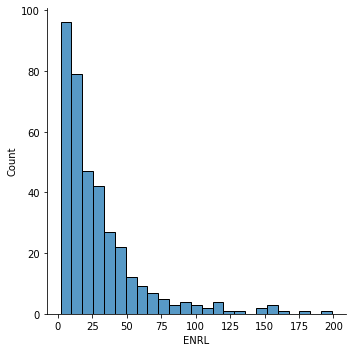

In [17]:
sns.displot(classes["ENRL"])

In [18]:
exams = classes

In [19]:
students.head(3)

,PERSON_IDENTIFIER,TERM_DESC,CRN,SUBJ_CODE,CRSE_NUMB,SECTION,SCHEDULE_TYPE,TITLE
0,1,Fall Semester 2022,10056,MATH,102,S03,LEC,SINGLE VARIABLE CALCULUS II
1,1,Fall Semester 2022,10074,PHYS,111,S01,LL,HONORS MECHANICS (WITH LAB)
2,1,Fall Semester 2022,11432,BUSI,223,001,LL,MODELING FOR ENTREPRENEURS


In [20]:
classrooms["OTR_ROOMTYPE"].unique()

array(['Classroom', 'Conference Room', 'Classroom - Flexible/SCALAR',
       'Lecture Hall', 'Computer Lab'], dtype=object)

In [21]:
students["SUBJ_CODE"] = students["SUBJ_CODE"]+"_"+students["CRSE_NUMB"].map(str)+"_"+students["SECTION"].map(str)
students.drop(columns = ["CRN", "TERM_DESC", "SCHEDULE_TYPE", "TITLE", "CRSE_NUMB", "SECTION"], inplace=True)
students = students[students['SUBJ_CODE'].isin(classes["SUBJ_CODE"])]
students.head(3)

,PERSON_IDENTIFIER,SUBJ_CODE
0,1,MATH_102_S03
1,1,PHYS_111_S01
5,2,MATH_212_S01


In [22]:
classrooms.sort_values("OTR_ROOMCAPACITY", ascending = False)

,OTR_BUILDINGCODE,OTR_BUILDINGNAME,OTR_ROOMTYPE,OTR_ROOMNUMBER,OTR_ROOMCAPACITY,OTR_SPECIALINFO
22,HRZ,Herzstein Hall,Lecture Hall,AMP,300,OTR: 24/7
31,KCK,Keck Hall,Lecture Hall,100,265,OTR: 24/7
72,DCH,Duncan Hall,Lecture Hall,1055,240,OTR: fall/spring - 6am-12:05pm Tue/Thu; Sch of...
14,HRG,Herring Hall,Lecture Hall,100,197,OTR: 24/7
50,LVC,Lovett College,Classroom - Flexible/SCALAR,COMMNS,184,"OTR: MWF 10-11 & 2-4, TR 9:25-10:40 & 2:30-3:4..."
...,...,...,...,...,...,...
57,BRC,BioScience Research Collaborative,Classroom,285,12,OTR: 24/7
54,BNC,Brown College,Conference Room,146,10,"OTR: summer - 24/7, fall/spring - 6am-5pm M-F;..."
40,KRF,Kraft Hall for Social Sciences,Classroom - Flexible/SCALAR,120,8,OTR: 24/7
63,MLC,Martel College,Conference Room,103,6,"OTR: summer - 24/7, fall/spring - 6am-5pm M-F;..."


In [23]:
exams[(exams["EXAM_TYPE"]=="Scheduled Final Exam-Dept Room") | (exams["EXAM_TYPE"]=='Scheduled Final Exam-OTR Room')].sort_values("ENRL", ascending = False).head(10)

,SUBJ_CODE,MEETING,ENRL,EXAM_TYPE
237,CHEM_211_S01,10:50AM - 12:05PM TR KCK 100,199,Scheduled Final Exam-OTR Room
125,BIOS_201_S01,09:00AM - 09:50AM MWF KCK 100,183,Scheduled Final Exam-OTR Room
848,PHYS_125_S01,09:25AM - 10:40AM TR HRZ AMP,166,Scheduled Final Exam-OTR Room
914,PSYC_101_002,10:50AM - 12:05PM TR SEW 301,158,Scheduled Final Exam-OTR Room
938,PSYC_101_003,01:00PM - 02:15PM TR SEW 301,158,Scheduled Final Exam-OTR Room
867,PHYS_101_S02,10:00AM - 10:50AM MW HRZ AMP,149,Scheduled Final Exam-OTR Room
150,BIOS_301_S01,11:00AM - 11:50AM MWF KCK 100,131,Scheduled Final Exam-OTR Room
643,MATH_101_S03,11:00AM - 11:50AM MWF SEW 301,124,Scheduled Final Exam-OTR Room
264,CHEM_121_S01,09:00AM - 09:50AM MWF BRK 101,120,Scheduled Final Exam-OTR Room
1038,STAT_310_001,01:00PM - 02:15PM TR HRZ AMP,113,Scheduled Final Exam-OTR Room


In [27]:
clusters = dict()

for i in range(1, 4638):
    combo = students[students["PERSON_IDENTIFIER"]==i]["SUBJ_CODE"].tolist()
    combo.sort()
    combo = tuple(combo)
    if (combo in clusters):
        clusters[combo] += 1
    else:
        clusters[combo] = 1
  
del clusters[()]

In [28]:
classrooms.head(2)

,OTR_BUILDINGCODE,OTR_BUILDINGNAME,OTR_ROOMTYPE,OTR_ROOMNUMBER,OTR_ROOMCAPACITY,OTR_SPECIALINFO
0,SEW,Sewall Hall,Classroom,460,20,OTR: 24/7
1,SEW,Sewall Hall,Conference Room,462,17,"OTR: summer - 24/7, fa/sp - wknds; 6am-12pm, 6..."


In [29]:
classrooms["OTR_BUILDINGCODE"] = classrooms["OTR_BUILDINGCODE"]+"_"+classrooms["OTR_ROOMNUMBER"]
classrooms.drop(columns=["OTR_ROOMNUMBER", "OTR_BUILDINGNAME","OTR_SPECIALINFO"], inplace=True)

In [30]:
classrooms.head(3)

,OTR_BUILDINGCODE,OTR_ROOMTYPE,OTR_ROOMCAPACITY
0,SEW_460,Classroom,20
1,SEW_462,Conference Room,17
2,SEW_560,Classroom,20


In [31]:
### Adding Days

new_classrooms = classrooms.copy()
new_classrooms["OTR_BUILDINGCODE"] = new_classrooms["OTR_BUILDINGCODE"]+"_day"+str(1)

for i in range(2, 8):
    new = classrooms.copy()
    new["OTR_BUILDINGCODE"] = new["OTR_BUILDINGCODE"]+"_day"+str(i)
    new_classrooms = new_classrooms.append(new.copy())
classrooms = new_classrooms

<ipython-input-31-2a2c54ace097>:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_classrooms = new_classrooms.append(new.copy())
<ipython-input-31-2a2c54ace097>:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_classrooms = new_classrooms.append(new.copy())
<ipython-input-31-2a2c54ace097>:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_classrooms = new_classrooms.append(new.copy())
<ipython-input-31-2a2c54ace097>:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  new_classrooms = new_classrooms.append(new.copy())
<ipython-input-31-2a2c54ace097>:9: FutureWarning: The frame.append method is deprecated and will be removed from pan

In [32]:
# Adding exam time (morning, noon, evening)

classrooms1 = classrooms.copy()
classrooms1["OTR_BUILDINGCODE"] = classrooms1["OTR_BUILDINGCODE"]+"_Morning"

classrooms2 = classrooms.copy()
classrooms2["OTR_BUILDINGCODE"] = classrooms2["OTR_BUILDINGCODE"]+"_Noon"

classrooms3 = classrooms.copy()
classrooms3["OTR_BUILDINGCODE"] = classrooms3["OTR_BUILDINGCODE"]+"_Evening"

slots = classrooms1.append(classrooms2).append(classrooms3)

<ipython-input-32-df44329f482e>:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  slots = classrooms1.append(classrooms2).append(classrooms3)
<ipython-input-32-df44329f482e>:12: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  slots = classrooms1.append(classrooms2).append(classrooms3)


In [33]:
slots.head()

,OTR_BUILDINGCODE,OTR_ROOMTYPE,OTR_ROOMCAPACITY
0,SEW_460_day1_Morning,Classroom,20
1,SEW_462_day1_Morning,Conference Room,17
2,SEW_560_day1_Morning,Classroom,20
3,SEW_562_day1_Morning,Conference Room,17
4,TUD_201_day1_Morning,Classroom,30


In [34]:
# Defining the online and in-person exams
all_exams = exams["SUBJ_CODE"]
person_exams = exams[(exams["EXAM_TYPE"] != 'Take-Home Exam') & (exams["EXAM_TYPE"] != 'Scheduled Online Final Exam')]["SUBJ_CODE"]
online_exams = exams[(exams["EXAM_TYPE"] == 'Take-Home Exam') | (exams["EXAM_TYPE"] == 'Scheduled Online Final Exam')]["SUBJ_CODE"]

# Creating "online" slots
for day in range(1, 8):
    for time in ["Morning", "Noon", "Evening"]:
        slots.loc[len(slots.index)] = ["online_day"+str(day)+"_"+time, "Online", 8000]
        
# Defining the online and in-person slots
slot_list = slots["OTR_BUILDINGCODE"].tolist()
online_slots = slots[slots["OTR_ROOMTYPE"]=="Online"]["OTR_BUILDINGCODE"].tolist()
person_slots = slots[slots["OTR_ROOMTYPE"]!="Online"]["OTR_BUILDINGCODE"].tolist()

# Defining the sections dictionary that will be scheduled at the same time
arr = [r[:-4] for r in exams["SUBJ_CODE"]]
arr.sort()

sections = {}
for course in arr:
    if course not in sections.keys() and arr.count(course) != 1:
        sections[course] = arr.count(course)

In [35]:
# (3049, 2205, 377)

# Inputs

# Model

In [58]:
x_vars = []
for i in slot_list:
    for j in all_exams:
        x_vars.append((i, j)) 
        
y_vars = []
for j in range(1, 7):
    for i in clusters.keys():
        y_vars.append((i, j))
        
z_vars = []
for i in person_slots:
    for j in person_exams:
        z_vars.append((i, j)) 

In [59]:
# helper function

def find_nth(haystack, needle, n):
    start = haystack.find(needle)
    while start >= 0 and n > 1:
        start = haystack.find(needle, start+len(needle))
        n -= 1
    return start

In [60]:
# Model
m = gp.Model("Model 1")

# Decision Variables
x = m.addVars(x_vars, vtype=GRB.BINARY, name = "x variables")
y= m.addVars(y_vars, lb = 0, name = "y variables") # number of extra exams in two consecutive days
z = m.addVars(z_vars, lb = 0, name = "z variables") # measure of capacity violations,0 otherwise

Set parameter Username
Academic license - for non-commercial use only - expires 2024-01-19


In [61]:
len(slot_list), len(person_slots), len(online_slots), len(all_exams), len(person_exams), len(online_exams)

(2226, 2205, 21, 372, 222, 150)

In [62]:
# Constraint 1: Xre = 0 if in person exam e requires more seats than of slot r has + lowebound for z

start = TIME.time()

exam_demand = {}
for e in person_exams:
    exam_demand[e] = exams[exams["SUBJ_CODE"] == e]["ENRL"].max()

slot_capacity = {}
for r in person_slots:
    slot_capacity[r] = slots[slots["OTR_BUILDINGCODE"]==r]["OTR_ROOMCAPACITY"].max()

for e in person_exams:
    for r in person_slots:
        De = exam_demand[e] # Demand
        Ce = slot_capacity[r] # Capacity
                
        # feasibility
        if Ce < De:
            m.addConstr(x[(r, e)] == 0, "Constraint 2")
            m.addConstr((z[r, e] == 0), "Constraint 1")
        else:
            # Lowebound for z
            m.addConstr((z[r, e] >= (2*De - Ce)*x[r, e]), "Constraint 1")


print(TIME.time() - start, "seconds")

8.69404935836792 seconds


In [63]:
for e in person_exams:
    for r in online_slots:
        m.addConstr(x[(r, e)] == 0, "Constraint 3: online slot with in person exam")

for e in online_exams:
    for r in person_slots:
        m.addConstr(x[(r, e)] == 0, "Constraint 4: in person slot with an online exam")

for e in person_exams:
    m.addConstr(gp.quicksum(x[(r, e)] for r in person_slots) == 1, "Constraint 5: match each in person exam to at least something")

for e in online_exams:
    m.addConstr(gp.quicksum(x[(r, e)] for r in online_slots) == 1, "Constraint 6: match each online exam to at least something")

for r in person_slots:
    m.addConstr(gp.quicksum(x[(r, e)] for e in person_exams) <= 1, "Constraint 7: no more than 1 exam per slot")

In [64]:
for i in range(1, 7):
    consecutive_slots = []
    for j in slot_list:
        if ("day"+str(i) in j) or ("day"+str(i+1) in j):
            consecutive_slots.append(j)
    for schedule in clusters.keys():
        m.addConstr(gp.quicksum(x[(r, e)] for r in consecutive_slots for e in schedule) <= 2 + y[schedule, i], "Constraint 8: y Violations")

In [65]:
# Sections at the same time
for course in sections.keys():
    V = []
    for i in all_exams:
        if course in i:
            V.append(i)
    e1 = V[0]
    
    for i in range(1, 8):
        for t in ["Morning", "Noon", "Evening"]:
            R_it = []
            for slot in slot_list:
                if ("day"+str(i)+"_" + t in slot):
                    R_it.append(slot)
            
            m.addConstr(gp.quicksum(x[(r, e)] for e in V for r in R_it) == 
                        sections[course]*gp.quicksum(x[(r, e1)] for r in R_it), "Constraint 9: sections at the same time")

In [66]:
# # Only ARCH classes in Anderson Hall

# building_slots = []
# for e in person_exams:
#     if e[:4] == "ARCH":
#         for r in person_slots:
#             if r[:3] == "ANH":
#                 building_slots.append(r)
#             else:
#                 if building_slots != []:
#                     m.addConstr(x[r, e] == 0, "Archi only in Anderson Hall")
#     else: 
#         if building_slots != []:
#             for r in building_slots:
#                 m.addConstr(x[r, e] == 0, "Non archi not in Anderson Hall")     

In [67]:
# # Only BUSI classes in McNeir Hall

# building_slots = []
# for e in person_exams:
#     if e[:4] == "BUSI":
#         for r in person_slots:
#             if r[:3] == "MCN":
#                 building_slots.append(r)
#             else:
#                 if building_slots != []
#                     m.addConstr(x[r, e] == 0, "busi only in McNeir Hall")
#     else:
#         if building_slots != []
#             for r in building_slots:
#                 m.addConstr(x[r, e] == 0, "Non busi not in McNeir Hall")     

In [68]:
# Set Objective & Optimize

### First objective: minimizes # of exam in consequtive days violations
obj1 = gp.quicksum(clusters[i[0]] * y[i] for i in y_vars)

### Second objective: minimizes capacity violations
obj2 = gp.quicksum(z[i] for i in z_vars)

m.setObjective(obj1+obj2, GRB.MINIMIZE)

In [91]:
# Set the time limit to 10 seconds
m.setParam('TimeLimit', 1000)

# Set the gap limit to 10%
m.setParam('MIPGap', 0.01)

# _________
m.optimize()

Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (win64)

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1031973 rows, 1337088 columns and 38989827 nonzeros
Model fingerprint: 0x594a2ba4
Variable types: 509016 continuous, 828072 integer (828072 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+02]
  Objective range  [1e+00, 3e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]
Presolved: 15367 rows, 318250 columns, 6549574 nonzeros

Continuing optimization...

  3094  1334  238.62217   16  635  264.00000  228.00000  13.6%   829 4059s
  3425  1426 infeasible   27       264.00000  228.00000  13.6%   832 4228s
  3584  1586  263.00000    8  586  264.00000  228.00000  13.6%   827 4435s
  3889  1685  263.00000   23  400  264.00000  228.00000  13.6%   824 4743s
  4095  1687     cutoff   27       264.00000  228.00000  13.6%   

In [92]:
to_split = []
for i in x_vars:
    if x[i].X > 0:
        arr.append(i)
        if i in z:
            if z[i].X > 0:
                to_split.append(i[1])
                print(z[i])

<gurobi.Var z variables[HRZ_AMP_day1_Morning,BIOS_201_S01] (value 66.0)>
<gurobi.Var z variables[HRZ_AMP_day1_Noon,PHYS_125_S01] (value 32.0)>
<gurobi.Var z variables[HRZ_AMP_day3_Noon,PSYC_101_002] (value 16.0)>
<gurobi.Var z variables[KCK_100_day3_Noon,PSYC_101_003] (value 51.0)>
<gurobi.Var z variables[HRZ_AMP_day7_Evening,CHEM_211_S01] (value 98.0)>


In [37]:
# to_split = ['BIOS_201_S01',
#  'PHYS_125_S01',
#  'PSYC_101_002',
#  'PSYC_101_003',
#  'CHEM_211_S01']

In [38]:
def do_split(to_split):
    ### Read the Data
    classrooms = pd.read_excel("Data/202310 Classroom Info.xlsx") # classrooms info
    classes = pd.read_excel("Data/202310 Schedule.xlsx") # class enrolment, meeting time, etc. info
    students = pd.read_excel("Data/202310 Student Registration.xlsx") # what classes students are taking in fall 2022
    actual = pd.read_excel("Data/202310 Final Exams.xlsx") # the actual matching of fall 2022

    # Compare with actual results
    TBA = actual[actual["BLDG_CODE"] == "TBA"]
    ONLINE = actual[actual["BLDG_CODE"]== "FULLY"]

    # actual = actual[actual["BLDG_CODE"] != "TBA"]
    # actual = actual[actual["BLDG_CODE"] != "FULLY"]

    actual["SUBJ_CODE"] = actual["SUBJ_CODE"]+"_"+actual["CRSE_NUMB"].map(str)+"_"+actual["SEQ_NUMB"].map(str)
    actual.drop(columns=["CRSE_NUMB", "SEQ_NUMB", "CRN"], inplace=True)

    actual["BLDG_CODE"] = actual["BLDG_CODE"]+"_"+actual["ROOM_CODE"].map(str)
    actual.drop(columns=["ROOM_CODE"], inplace=True)

    actual_exam_list = actual["SUBJ_CODE"].tolist()
    classes = classes[["SUBJ_CODE", "CRSE_NUMB", "MEETING", "SEQ_NUMB", "ENRL", "EXAM_TYPE"]]
    classes["SUBJ_CODE"] = classes["SUBJ_CODE"]+"_"+classes["CRSE_NUMB"].map(str)+"_"+classes["SEQ_NUMB"].map(str)
    classes.drop(columns = ["CRSE_NUMB", "SEQ_NUMB"], inplace=True)
    classes = classes[classes["EXAM_TYPE"] != 'No Final Exam']
    classes = classes[classes["ENRL"]>1]
    ### We want to only consider the common exams between actual and given data for comparison
    common_exams = []
    for i in classes["SUBJ_CODE"].tolist():
        if i in actual["SUBJ_CODE"].tolist():
            common_exams.append(i)
    classes = classes[classes["SUBJ_CODE"].isin(common_exams)]
    actual = actual[actual["SUBJ_CODE"].isin(common_exams)]
    exams = classes
    students["SUBJ_CODE"] = students["SUBJ_CODE"]+"_"+students["CRSE_NUMB"].map(str)+"_"+students["SECTION"].map(str)
    students.drop(columns = ["CRN", "TERM_DESC", "SCHEDULE_TYPE", "TITLE", "CRSE_NUMB", "SECTION"], inplace=True)
    students = students[students['SUBJ_CODE'].isin(classes["SUBJ_CODE"])]
    students.head(3)
    classrooms.sort_values("OTR_ROOMCAPACITY", ascending = False)
    exams[(exams["EXAM_TYPE"]=="Scheduled Final Exam-Dept Room") | (exams["EXAM_TYPE"]=='Scheduled Final Exam-OTR Room')].sort_values("ENRL", ascending = False).head(10)
#     to_split = exams[(exams["EXAM_TYPE"]=="Scheduled Final Exam-Dept Room") | (exams["EXAM_TYPE"]=='Scheduled Final Exam-OTR Room')][exams["ENRL"] >= 150]["SUBJ_CODE"].tolist()
    for big in to_split:
        students_to_change = students[students["SUBJ_CODE"] == big]["PERSON_IDENTIFIER"].tolist()
        students_to_change.sort()

        first = big+"_SPLIT1"
        second = big+"_SPLIT2"
        enrl = len(students_to_change)
        meeting = exams[exams["SUBJ_CODE"] == big]["MEETING"].max()
        etype =exams[exams["SUBJ_CODE"] == big]["EXAM_TYPE"].max()

        # remove it from exams df
        exams = exams[exams["SUBJ_CODE"] != big]

        # add them to exams df
        first_row = {'SUBJ_CODE': first, 'MEETING': meeting, 'ENRL': enrl//2, "EXAM_YPE": etype}
        second_row = {'SUBJ_CODE': second, 'MEETING': meeting, 'ENRL': enrl - enrl//2, "EXAM_YPE": etype}
        exams = exams.append(first_row, ignore_index = True)
        exams = exams.append(second_row, ignore_index = True)



        if len(students_to_change) != enrl:
            print(len(students_to_change) - enrl)
        for i in range(enrl//2):
            person = students_to_change[i]
            students.loc[len(students.index)] = [person, first]
        for i in range(enrl//2, enrl):
            person = students_to_change[i]
            students.loc[len(students.index)] = [person, second]

        # remove big
        students = students[students["SUBJ_CODE"] != big]
    clusters = dict()

    for i in range(1, 4638):
        combo = students[students["PERSON_IDENTIFIER"]==i]["SUBJ_CODE"].tolist()
        combo.sort()
        combo = tuple(combo)
        if (combo in clusters):
            clusters[combo] += 1
        else:
            clusters[combo] = 1

    del clusters[()]
    classrooms["OTR_BUILDINGCODE"] = classrooms["OTR_BUILDINGCODE"]+"_"+classrooms["OTR_ROOMNUMBER"]
    classrooms.drop(columns=["OTR_ROOMNUMBER", "OTR_BUILDINGNAME","OTR_SPECIALINFO"], inplace=True)

    ### Adding Days

    new_classrooms = classrooms.copy()
    new_classrooms["OTR_BUILDINGCODE"] = new_classrooms["OTR_BUILDINGCODE"]+"_day"+str(1)

    for i in range(2, 8):
        new = classrooms.copy()
        new["OTR_BUILDINGCODE"] = new["OTR_BUILDINGCODE"]+"_day"+str(i)
        new_classrooms = new_classrooms.append(new.copy())
    classrooms = new_classrooms
    # Adding exam time (morning, noon, evening)

    classrooms1 = classrooms.copy()
    classrooms1["OTR_BUILDINGCODE"] = classrooms1["OTR_BUILDINGCODE"]+"_Morning"

    classrooms2 = classrooms.copy()
    classrooms2["OTR_BUILDINGCODE"] = classrooms2["OTR_BUILDINGCODE"]+"_Noon"

    classrooms3 = classrooms.copy()
    classrooms3["OTR_BUILDINGCODE"] = classrooms3["OTR_BUILDINGCODE"]+"_Evening"

    slots = classrooms1.append(classrooms2).append(classrooms3)
    # Defining the online and in-person exams
    all_exams = exams["SUBJ_CODE"]
    person_exams = exams[(exams["EXAM_TYPE"] != 'Take-Home Exam') & (exams["EXAM_TYPE"] != 'Scheduled Online Final Exam')]["SUBJ_CODE"]
    online_exams = exams[(exams["EXAM_TYPE"] == 'Take-Home Exam') | (exams["EXAM_TYPE"] == 'Scheduled Online Final Exam')]["SUBJ_CODE"]

    # Creating "online" slots
    for day in range(1, 8):
        for time in ["Morning", "Noon", "Evening"]:
            slots.loc[len(slots.index)] = ["online_day"+str(day)+"_"+time, "Online", 8000]

    # Defining the online and in-person slots
    slot_list = slots["OTR_BUILDINGCODE"].tolist()
    online_slots = slots[slots["OTR_ROOMTYPE"]=="Online"]["OTR_BUILDINGCODE"].tolist()
    person_slots = slots[slots["OTR_ROOMTYPE"]!="Online"]["OTR_BUILDINGCODE"].tolist()

    # Defining the sections dictionary that will be scheduled at the same time
    arr = [r[:-4] for r in exams["SUBJ_CODE"]]
    arr.sort()

    sections = {}
    for course in arr:
        if course not in sections.keys() and arr.count(course) != 1:
            sections[course] = arr.count(course)
            
    
    return all_exams, slot_list, person_slots, online_slots, person_exams, clusters, online_exams, slots, exams, sections

In [39]:
all_exams, slot_list, person_slots, online_slots, person_exams, clusters, online_exams, slots, exams, sections = do_split(to_split)

<ipython-input-38-bf076459e766>:58: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  exams = exams.append(first_row, ignore_index = True)
<ipython-input-38-bf076459e766>:59: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  exams = exams.append(second_row, ignore_index = True)
<ipython-input-38-bf076459e766>:58: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  exams = exams.append(first_row, ignore_index = True)
<ipython-input-38-bf076459e766>:59: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  exams = exams.append(second_row, ignore_index = True)
<ipython-input-38-bf076459e766>:58: FutureWarning: The frame.append method is deprecated and will be r

# Second Part (first need to run everything but model)

In [40]:
x_vars = []
for i in slot_list:
    for j in all_exams:
        x_vars.append((i, j)) 
        
y_vars = []
for j in range(1, 7):
    for i in clusters.keys():
        y_vars.append((i, j))
        
z_vars = []
for i in person_slots:
    for j in person_exams:
        z_vars.append((i, j)) 

In [41]:
# Model
m2 = gp.Model("Model 2")

# Decision Variables
x = m2.addVars(x_vars, vtype=GRB.BINARY, name = "x variables")
y= m2.addVars(y_vars, lb = 0, name = "y variables") # number of extra exams in two consecutive days
z = m2.addVars(z_vars, lb = 0, name = "z variables") # measure of capacity violations,0 otherwise

Set parameter Username
Academic license - for non-commercial use only - expires 2024-01-19


In [42]:
# Constraint 1: Xre = 0 if in person exam e requires more seats than of slot r has + lowebound for z

start = TIME.time()

exam_demand = {}
for e in person_exams:
    exam_demand[e] = exams[exams["SUBJ_CODE"] == e]["ENRL"].max()

slot_capacity = {}
for r in person_slots:
    slot_capacity[r] = slots[slots["OTR_BUILDINGCODE"]==r]["OTR_ROOMCAPACITY"].max()

for e in person_exams:
    for r in person_slots:
        De = exam_demand[e] # Demand
        Ce = slot_capacity[r] # Capacity
                
        # feasibility
        if Ce < 2*De: # BIG CHANGE HERE!
            m2.addConstr(x[(r, e)] == 0, "Constraint 2")
            m2.addConstr((z[r, e] == 0), "Constraint 1")
        else:
            # Lowebound for z
            m2.addConstr((z[r, e] >= (2*De - Ce)*x[r, e]), "Constraint 1")


print(TIME.time() - start, "seconds")

9.715492486953735 seconds


In [43]:
for e in person_exams:
    for r in online_slots:
        m2.addConstr(x[(r, e)] == 0, "Constraint 3: online slot with in person exam")

for e in online_exams:
    for r in person_slots:
        m2.addConstr(x[(r, e)] == 0, "Constraint 4: in person slot with an online exam")

for e in person_exams:
    m2.addConstr(gp.quicksum(x[(r, e)] for r in person_slots) == 1, "Constraint 5: match each in person exam to at least something")

for e in online_exams:
    m2.addConstr(gp.quicksum(x[(r, e)] for r in online_slots) == 1, "Constraint 6: match each online exam to at least something")

for r in person_slots:
    m2.addConstr(gp.quicksum(x[(r, e)] for e in person_exams) <= 1, "Constraint 7: no more than 1 exam per slot")

In [44]:
for i in range(1, 7):
    consecutive_slots = []
    for j in slot_list:
        if ("day"+str(i) in j) or ("day"+str(i+1) in j):
            consecutive_slots.append(j)
    for schedule in clusters.keys():
        m2.addConstr(gp.quicksum(x[(r, e)] for r in consecutive_slots for e in schedule) <= 2 + y[schedule, i], "Constraint 8: y Violations")

In [45]:
# Sections at the same time
for course in sections.keys():
    V = []
    for i in all_exams:
        if course in i:
            V.append(i)
    e1 = V[0]
    
    for i in range(1, 8):
        for t in ["Morning", "Noon", "Evening"]:
            R_it = []
            for slot in slot_list:
                if ("day"+str(i)+"_" + t in slot):
                    R_it.append(slot)
            
            m2.addConstr(gp.quicksum(x[(r, e)] for e in V for r in R_it) == 
                        sections[course]*gp.quicksum(x[(r, e1)] for r in R_it), "Constraint 9: sections at the same time")

In [58]:
bldg_by_code = {}
for bgn in np.unique([code[:3] for code in actual["BLDG_CODE"]]):
    for sloti in slot_list:
        if bgn in sloti:
            if bgn not in bldg_by_code:
                bldg_by_code[bgn] = []
            bldg_by_code[bgn].append(sloti)

In [72]:
weights = {}
for i in range(len(actual)):
    exam = actual.iloc[i]["SUBJ_CODE"]
    bldg = actual.iloc[i]["BLDG_CODE"]
    
    if bldg == "TBA_TBA":
        continue
    
    if exam not in all_exams.tolist():
        continue
    
    for k in range(1, 8):
        for j in ["Morning", "Noon", "Evening"]:
            if bldg[:3] in bldg_by_code:
                for sloti in bldg_by_code[bldg[:3]]:
                    weights[(sloti, exam)] = 0.5
            
            sloti = bldg+"_" + "day"+str(k)+"_"+j
            weights[(sloti, exam)] = 1

In [74]:
w = 1
i = 0
for s in slot_list:
    for i in range(1, 8):
        if "day"+str(i) in s:
            w= int(i)
            break    
    for e in all_exams:
        if (s, e) not in weights.keys():
            weights[(s, e)] = w
        else:
            weights[(s, e)] += w

In [86]:
# Third Objective

### First objective: minimizes # of exam in consequtive days violations
obj1 = gp.quicksum(10*clusters[i[0]] * y[i] for i in y_vars)

### Second objective: z-violation measure
# obj2 = gp.quicksum(z[i] for i in z_vars) - in the constraint

### Third objective: preference
obj3 = gp.quicksum(x[s, e] * weights[s, e] for s in slot_list for e in all_exams)

### Set the objectives
m2.setObjective(obj1+obj3, GRB.MINIMIZE)

Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (win64)

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1214924 rows, 1430409 columns and 38720511 nonzeros
Model fingerprint: 0x607b5c79
Variable types: 551139 continuous, 879270 integer (879270 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+02]
  Objective range  [1e+00, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]

Processing MIP start from previous solve: 0 nodes explored in subMIP, total elapsed time 7s
Processing MIP start from previous solve: 0 nodes explored in subMIP, total elapsed time 11s
MIP start from previous solve produced solution with objective 1506.5 (11.20s)
Loaded MIP start from previous solve with objective 1506.5
Processed MIP start in 11.17 seconds (4.31 work units)

Presolve removed 531405 rows and 531405 columns (presolve time = 5s) .

In [94]:
# Set the time limit to 10 seconds
m2.setParam('TimeLimit', 300)

# Set the gap limit to 10%
m2.setParam('MIPGap', 0.1)

m2.optimize()

Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (win64)

CPU model: AMD Ryzen 5 4600H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1214924 rows, 1430409 columns and 38720511 nonzeros
Model fingerprint: 0x607b5c79
Variable types: 551139 continuous, 879270 integer (879270 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+02]
  Objective range  [1e+00, 3e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 2e+00]
Presolved: 15074 rows, 228381 columns, 3693412 nonzeros

Continuing optimization...

     0     0  835.66190    0  828 1420.50000  835.66190  41.2%     -  347s
     0     0  835.66190    0  844 1420.50000  835.66190  41.2%     -  350s
     0     0  835.66190    0  828 1420.50000  835.66190  41.2%     -  355s
     0     2  835.66190    0  828 1420.50000  835.66190  41.2%     -  384s
     1     4  838.75415    1  903 1420.50000  835.66394  41.2%  5

In [95]:
for i in z_vars:
    if z[i].X > 0:
        print(z[i])

In [96]:
for j in x_vars[:]:
    if x[j].X == 1.0:
        print(j)

('SEW_562_day1_Morning', 'CHEM_430_001')
('TUD_201_day1_Morning', 'STAT_315_007')
('WSC_123_day1_Morning', 'POLI_324_001')
('WSC_146_day1_Morning', 'CHEM_201_001')
('HBH_227_day1_Morning', 'CEVE_211_001')
('HBH_423_day1_Morning', 'MECH_450_001')
('ABL_131_day1_Morning', 'STAT_315_005')
('HRG_100_day1_Morning', 'BIOS_300_001')
('HRZ_210_day1_Morning', 'COMP_310_001')
('HRZ_212_day1_Morning', 'COMP_310_002')
('HRZ_AMP_day1_Morning', 'BIOS_341_S01')
('HUM_117_day1_Morning', 'CHBE_301_002')
('HUM_119_day1_Morning', 'BIOE_385_002')
('HUM_327_day1_Morning', 'THEA_103_001')
('KCK_100_day1_Morning', 'MATH_111_S01')
('KCK_101_day1_Morning', 'BIOE_385_004')
('KCK_102_day1_Morning', 'CHBE_470_002')
('KRF_105_day1_Morning', 'LING_401_001')
('KRF_110_day1_Morning', 'EEPS_322_001')
('KRF_120_day1_Morning', 'BIOE_422_001')
('KWG_100_day1_Morning', 'MECH_343_001')
('KWG_130_day1_Morning', 'STAT_315_006')
('BKH_102_day1_Morning', 'EEPS_418_001')
('MCA_103_day1_Morning', 'NAVA_403_001')
('MCA_210_day1_M

('KCK_100_day3_Evening', 'CHEM_211_S01_SPLIT1')
('KCK_102_day3_Evening', 'ENGI_210_004')
('KRF_125_day3_Evening', 'DSCI_301_005')
('LVC_COMMNS_day3_Evening', 'BUSI_305_002')
('BRC_284_day3_Evening', 'CEVE_471_001')
('MXF_251_day3_Evening', 'MECH_412_001')
('MXF_252_day3_Evening', 'HART_118_001')
('DCH_1020 / SYM II_day3_Evening', 'PHYS_111_S01')
('DCH_1042_day3_Evening', 'POLI_260_003')
('DCH_1055_day3_Evening', 'BUSI_305_003')
('DCH_1064_day3_Evening', 'EEPS_116_001')
('DCH_1070_day3_Evening', 'CHBE_390_003')
('GRW_160A_day3_Evening', 'BIOE_420_001')
('PCF_3_day3_Evening', 'BIOE_451_001')
('PCF_4_day3_Evening', 'BUSI_343_002')
('RYN_201_day3_Evening', 'HART_101_001')
('RZR_119_day3_Evening', 'CMST_203_001')
('RZR_205_day3_Evening', 'ECON_307_001')
('SEW_309_day3_Evening', 'PHYS_201_001')
('HRG_126_day5_Evening', 'BIOE_464_001')
('HRZ_212_day5_Evening', 'ECON_483_001')
('HRZ_AMP_day5_Evening', 'MATH_355_001')
('KCK_100_day5_Evening', 'BIOS_301_S01')
('KWG_100_day5_Evening', 'ELEC_303_0

In [97]:
count = 0
for k in y_vars:
    if y[k].X > 0:
        count += k[1]*y[k].X
        print(k[1]," students taking extra " , y[k].X)

1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
1  students taking extra  1.0
2  students taking extra  1.0
2  students taking extra  1.0
3  students taking extra  1.0
3  students taking extra  1.0
5  students taking extra  1.0
5  students taking extra  1.0
5  students taking extra  1.0
5  students taking extra  1.0
5  students taking extra  1.0
5  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  2.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  students taking extra  1.0
6  student

In [98]:
print(count)

#count = 306.0

147.0
